# Demo Analysis

This notebook demonstrates the `journal_alignment` package. The implementation stays in `src/journal_alignment/`.

## 1. Setup

Run this notebook from the repository root (`nlp/`) so the default project paths resolve correctly.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from journal_alignment import ProjectConfig
from journal_alignment.pipeline import AlignmentPipeline

## 2. Load configuration

The default configuration expects the raw PubMed CSV and Aims & Scope text file under `data/raw/`.

In [2]:
config = ProjectConfig()

config_summary = pd.DataFrame(
    {
        "setting": [
            "articles_path",
            "aims_scope_path",
            "results_dir",
            "figures_dir",
            "tables_dir",
            "model_name",
            "top_n",
        ],
        "value": [
            config.articles_path,
            config.aims_scope_path,
            config.results_dir,
            config.figures_dir,
            config.tables_dir,
            config.model_name,
            config.top_n,
        ],
    }
)
display(config_summary)

,setting,value
0,articles_path,..\data\raw\articles_pubmed.csv
1,aims_scope_path,..\data\raw\aims_scope.txt
2,results_dir,..\data\results
3,figures_dir,..\reports\figures
4,tables_dir,..\reports\tables
5,model_name,sentence-transformers/all-MiniLM-L6-v2
6,top_n,10


## 3. Run pipeline

The pipeline loads the inputs, computes alignment scores, saves CSV outputs, and creates plots.

In [3]:
pipeline = AlignmentPipeline(config)
results = pipeline.run()

list(results.keys())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (263 > 256). Running this sequence through the model will result in indexing errors


['alignment_scores',
 'summary_statistics',
 'yearly_alignment',
 'top_aligned_articles',
 'least_aligned_articles',
 'outlier_articles']

## 4. Article-level scores

The main output contains one row per article with semantic and TF-IDF alignment scores.

In [4]:
article_scores = results["alignment_scores"]
article_columns = [
    "pmid",
    "title",
    "year",
    "alignment_score",
    "tfidf_alignment_score",
    "is_outlier",
]
display(article_scores[[column for column in article_columns if column in article_scores.columns]].head())

,pmid,title,year,alignment_score,tfidf_alignment_score,is_outlier
0,41695741,"Orthopedic trinity: Arthroscopy, sports medici...",2026,0.614094,0.171738,True
1,41695740,Laminectomy alone vs laminectomy with posterio...,2026,0.312070,0.098022,False
2,41695739,Early dislocation in primary total hip arthrop...,2026,0.345264,0.180393,False
3,41695738,Phosphatidylinositol-3-kinase/protein kinase B...,2026,0.222211,0.068595,False
4,41695737,Impact of preoperative frailty on complication...,2026,0.320476,0.063505,False


## 5. Yearly scores

The yearly table aggregates article-level alignment scores by publication year.

In [5]:
display(results["yearly_alignment"])

,year,count,mean,median,std,min,max
0,2016,111,0.323217,0.327908,0.082049,0.034925,0.520259
1,2017,125,0.328059,0.328879,0.078364,0.106946,0.581535
2,2018,40,0.341620,0.344167,0.063387,0.198016,0.462076
3,2019,48,0.345849,0.342038,0.070041,0.199846,0.497625
4,2020,64,0.355588,0.346904,0.085036,0.184632,0.557726
5,2021,98,0.358014,0.347586,0.095821,0.156974,0.747456
6,2022,102,0.349066,0.350868,0.077663,0.139016,0.560629
7,2023,90,0.342621,0.339698,0.079988,0.126759,0.642153
8,2024,140,0.345036,0.341992,0.081448,0.085009,0.592074
9,2025,163,0.348683,0.353034,0.077568,0.123912,0.562977


## 6. Top and bottom articles

These tables show the highest and lowest scoring articles according to the embedding alignment score.

In [6]:
ranking_columns = ["pmid", "title", "year", "alignment_score", "tfidf_alignment_score"]

top_articles = results["top_aligned_articles"]
bottom_articles = results["least_aligned_articles"]

display(top_articles[[column for column in ranking_columns if column in top_articles.columns]])
display(bottom_articles[[column for column in ranking_columns if column in bottom_articles.columns]])

,pmid,title,year,alignment_score,tfidf_alignment_score
0,33614424,New Year's greeting and overview of World Jour...,2021,0.747456,0.230183
1,33816143,Bibliometric analysis of research on the effec...,2021,0.675017,0.122559
2,37662667,Scientific publications on orthopedic surgery ...,2023,0.642153,0.151271
3,41695741,"Orthopedic trinity: Arthroscopy, sports medici...",2026,0.614094,0.171738
4,39473512,Research trends in exercise therapy for the tr...,2024,0.592074,0.182604
5,34754830,Surgical treatment of metastatic bone disease ...,2021,0.582920,0.156534
6,28660144,Worldwide orthopaedic research activity 2010-2...,2017,0.581535,0.115404
7,37662661,In vitro laboratory infection research in orth...,2023,0.566990,0.140433
8,38464353,Limb Lengthening and Reconstruction Society or...,2024,0.563859,0.105789
9,41480508,Advancing global orthopedic research through c...,2025,0.562977,0.166639


,pmid,title,year,alignment_score,tfidf_alignment_score
0,28032039,Glomus tumors of the fingers: Expression of va...,2016,0.034925,0.071253
1,38596192,New method of local adjuvant therapy with bica...,2024,0.085009,0.057976
2,29312846,Role of fast-setting cements in arthroplasty: ...,2017,0.106946,0.054339
3,40547242,Arthroscopic management of a rare free-edge me...,2025,0.123912,0.064434
4,37970623,Vancomycin flushing syndrome in orthopaedic pr...,2023,0.126759,0.076020
5,27622153,Slacklining and stroke: A rehabilitation case ...,2016,0.130100,0.072791
6,39850033,Role of neurogenic inflammation in interverteb...,2025,0.138327,0.060431
7,36439370,Genetics of congenital anomalies of the hand.,2022,0.139016,0.110935
8,35949710,Reducing bacterial adhesion to titanium surfac...,2022,0.142322,0.072933
9,35949706,"Content of blood cell components, inflammatory...",2022,0.144530,0.095100


## 7. Saved visualizations

The pipeline saves standard plots under `reports/figures/`.

..\reports\figures\alignment_histogram.png


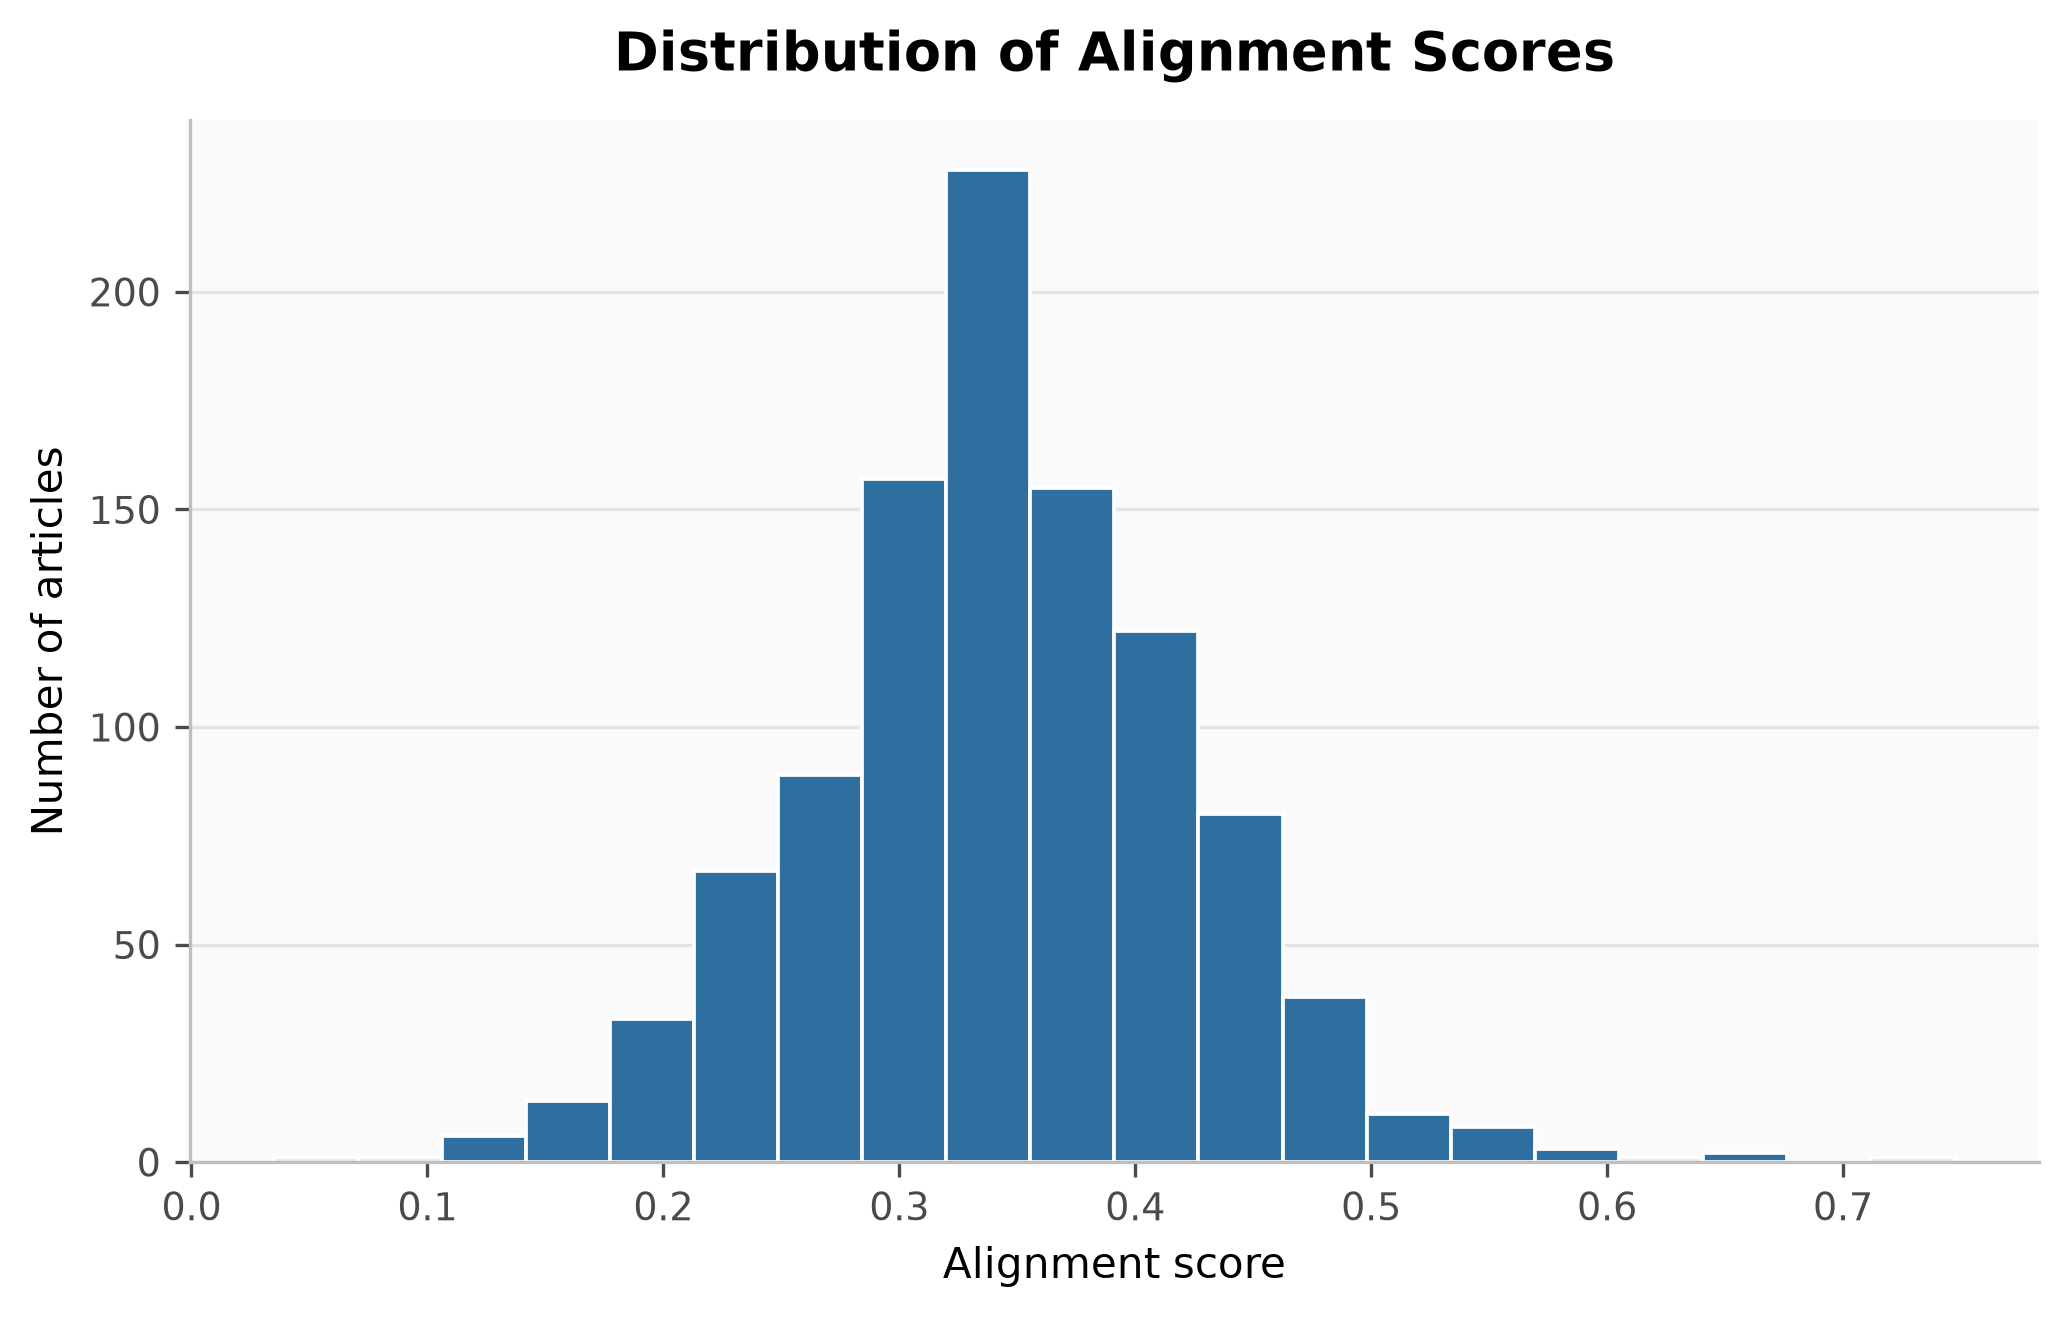

..\reports\figures\alignment_boxplot.png


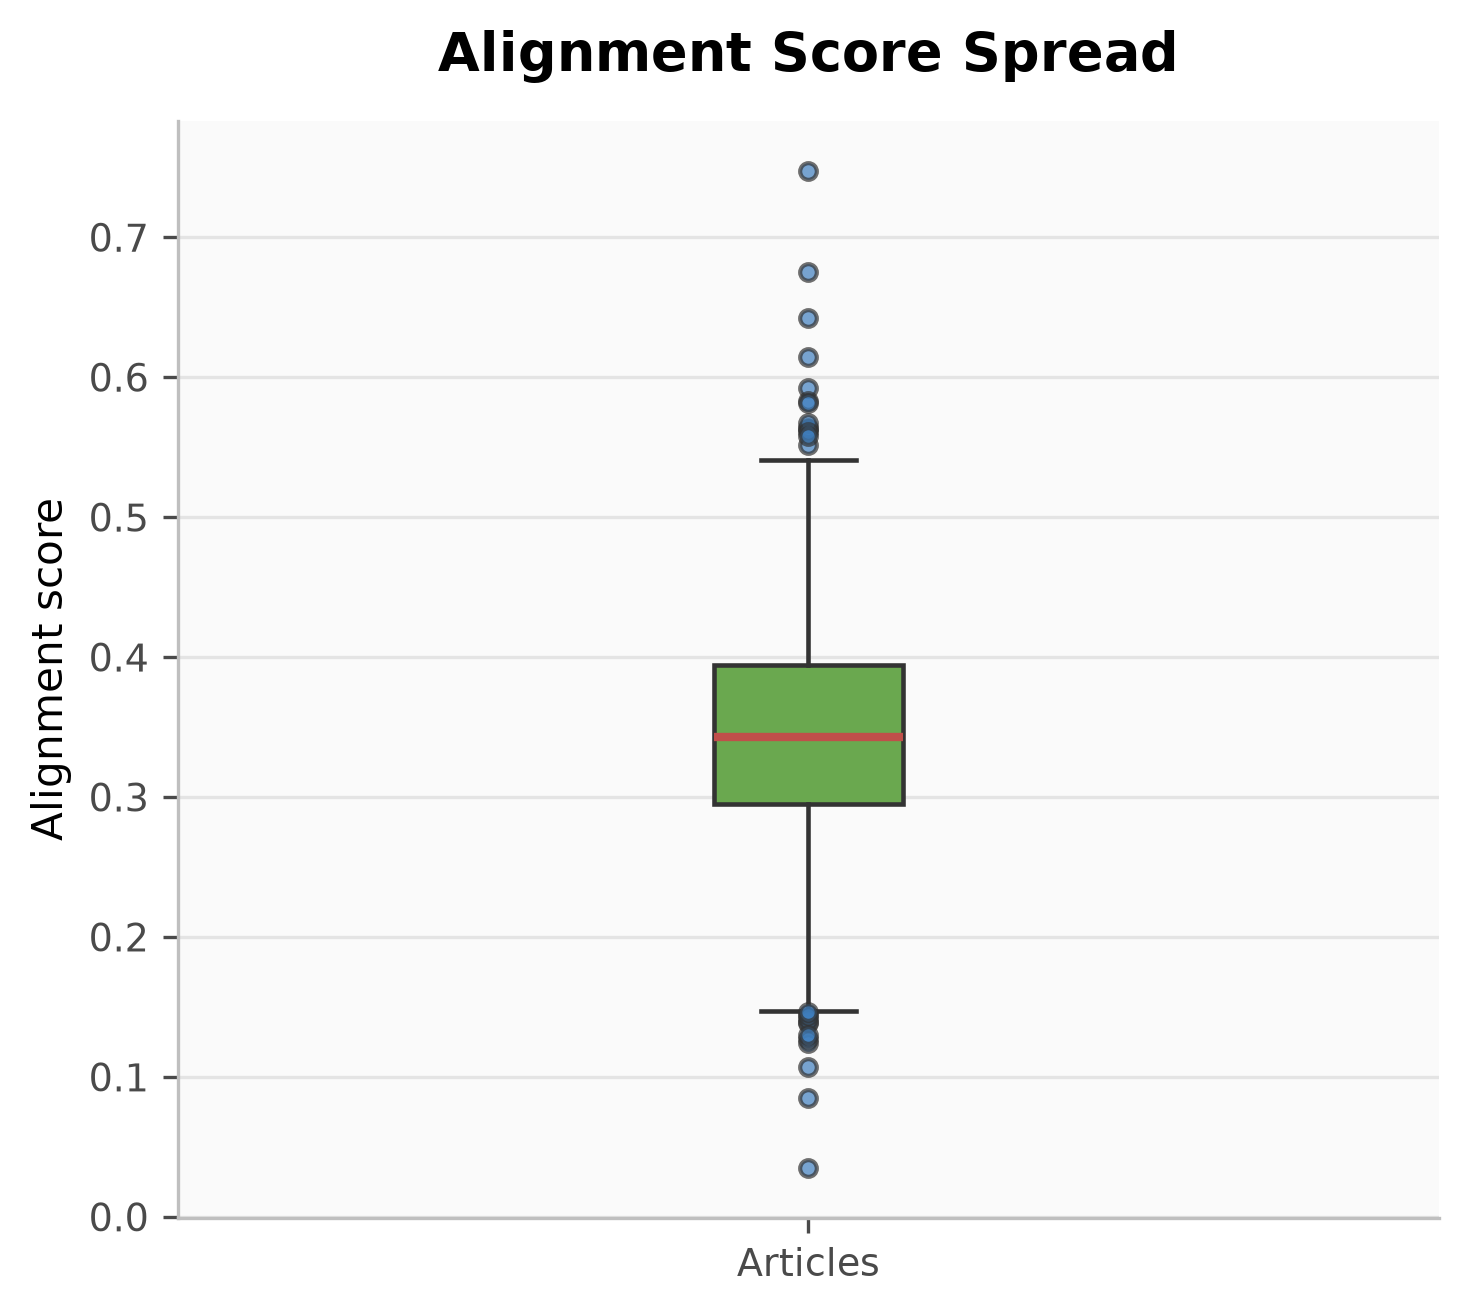

..\reports\figures\alignment_by_year.png


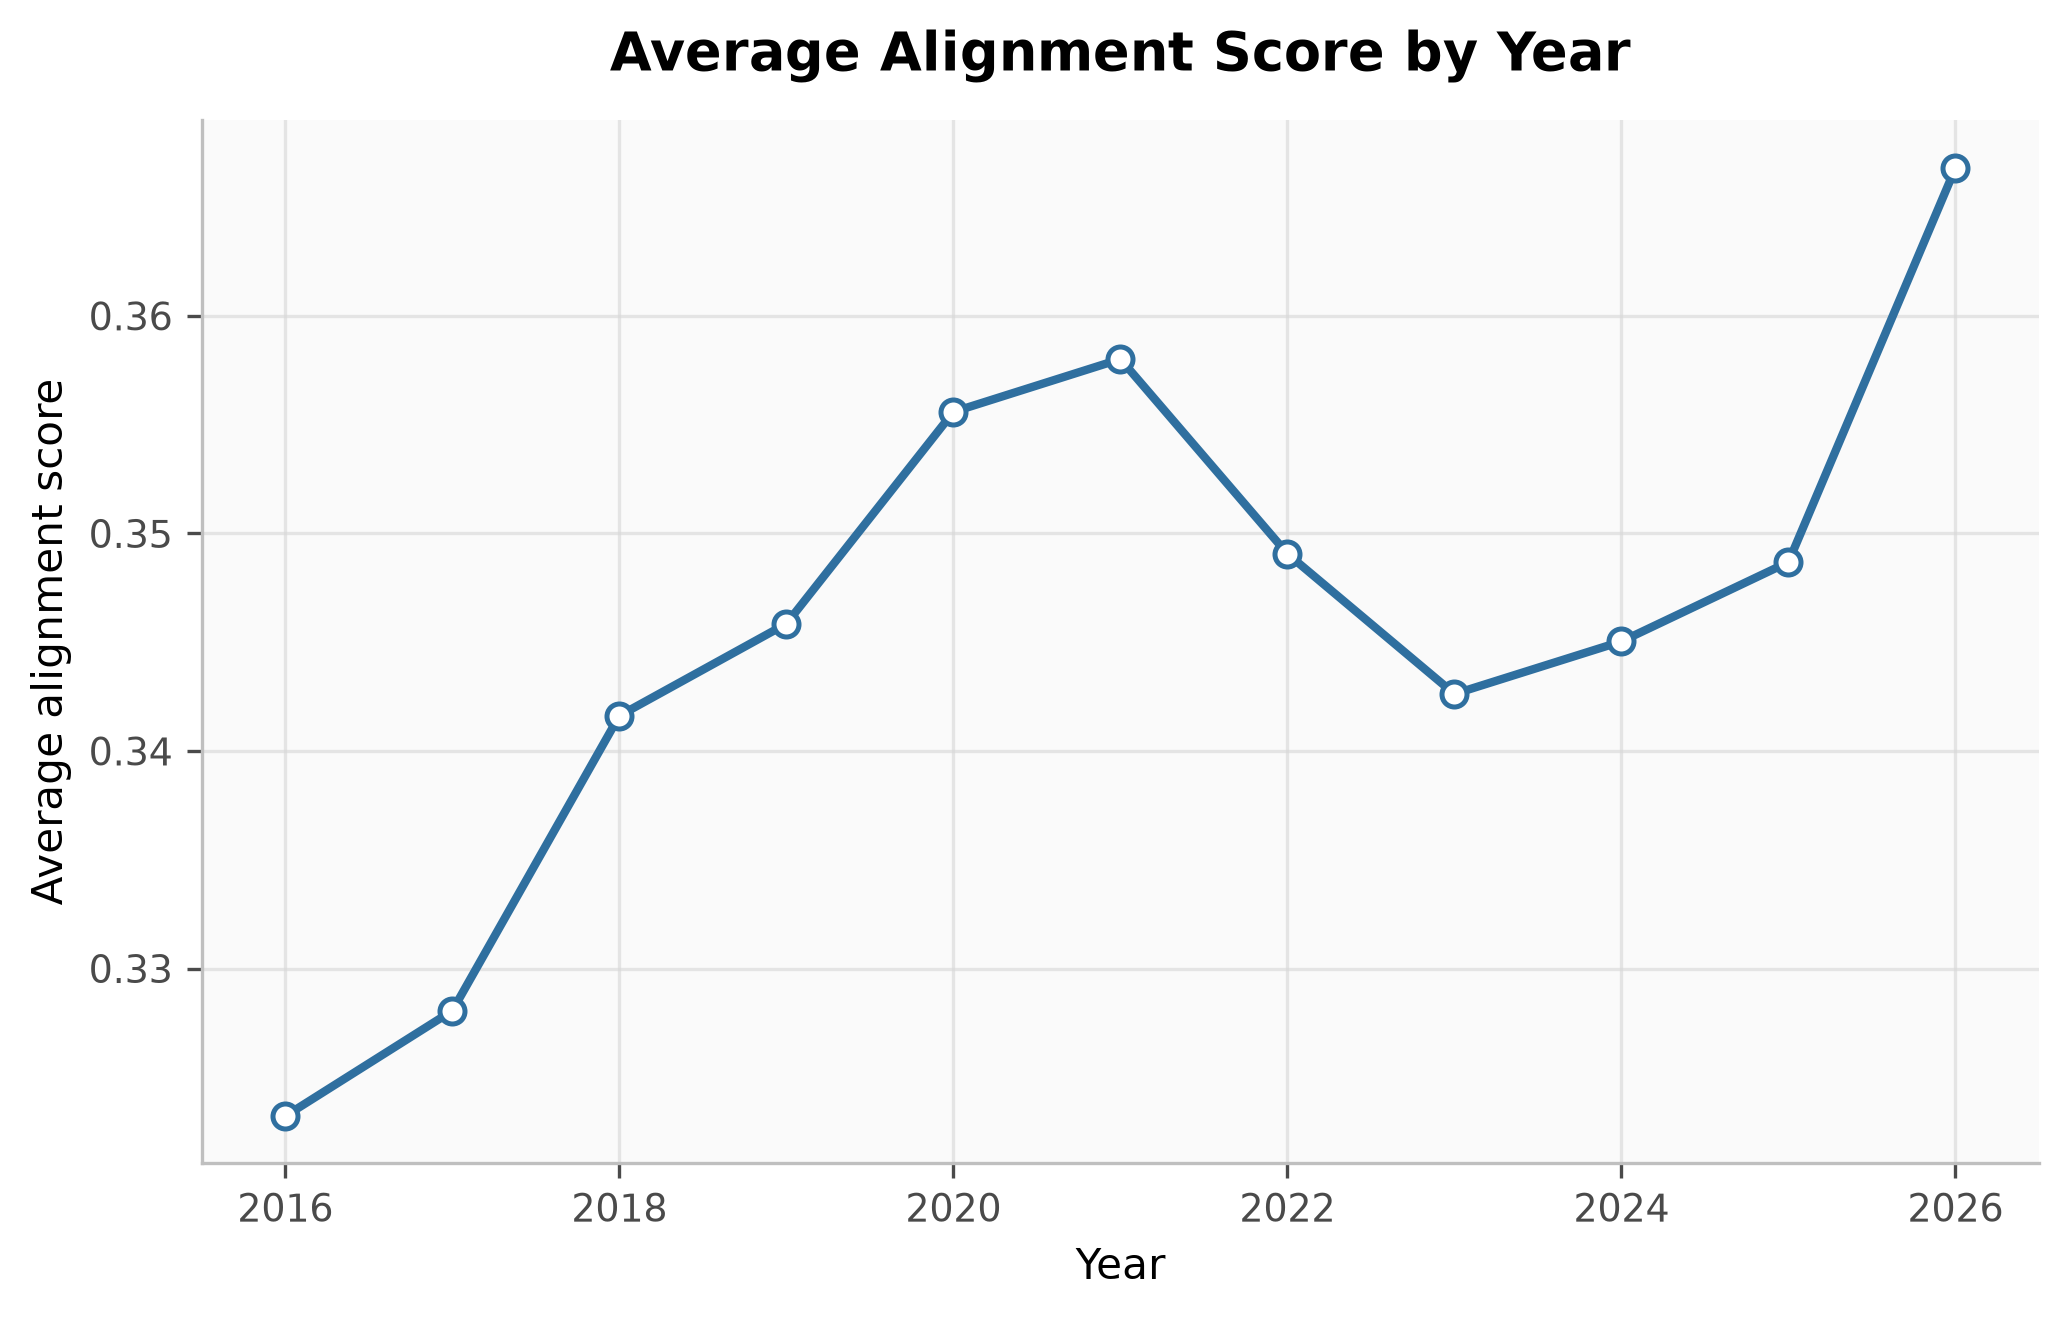

..\reports\figures\article_scores_by_year.png


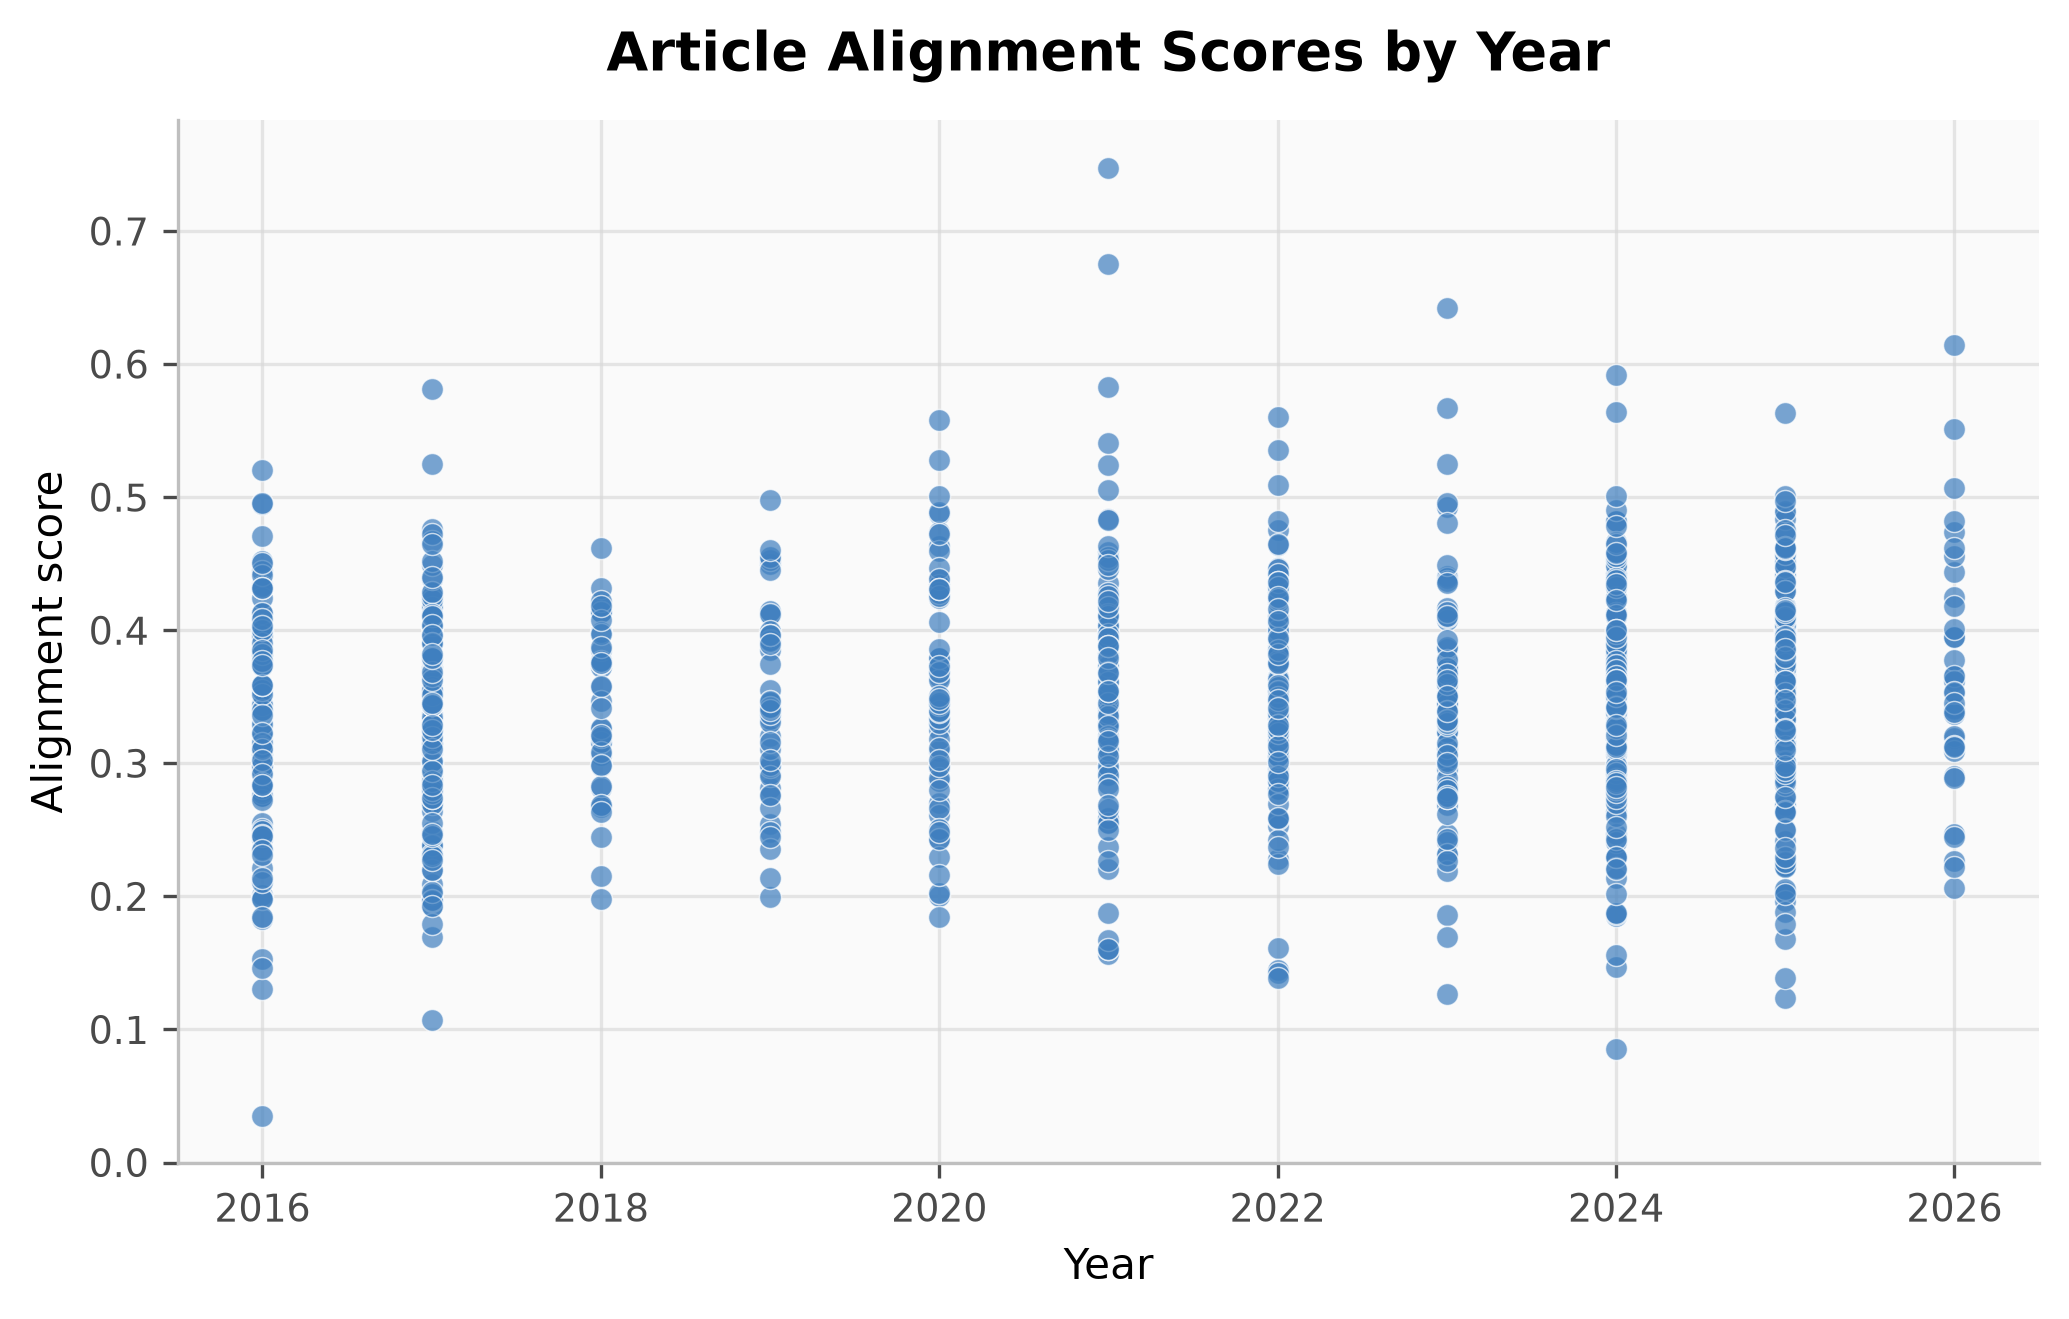

In [7]:
figure_paths = [
    config.figures_dir / "alignment_histogram.png",
    config.figures_dir / "alignment_boxplot.png",
    config.figures_dir / "alignment_by_year.png",
    config.figures_dir / "article_scores_by_year.png",
]

for figure_path in figure_paths:
    print(figure_path)
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print("Plot not found. Run the pipeline cell first.")